In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [2]:
PROJECT_ROOT = Path("/Users/apple/Desktop/UCL/skills/python3")
EMBEDDINGS_DIR = PROJECT_ROOT / "data" / "embeddings"
OUTPUTS_DIR = PROJECT_ROOT / "outputs" / "plots"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

all_df = pd.read_csv(EMBEDDINGS_DIR / "all_texts_with_labels.csv")
sentence_embeddings = np.load(EMBEDDINGS_DIR / "sentence_embeddings.npy")

In [3]:
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(sentence_embeddings)

all_df["cluster"] = cluster_labels
all_df.head()

,dataset,source,page_title,text_id,raw_text,cleaned_text,word_count,dataset_label,cluster
0,landforms,wikipedia,Desert,Desert_0,A desert is a landscape where little precipita...,A desert is a landscape where little precipita...,91,landforms,5
1,landforms,wikipedia,Desert,Desert_1,Deserts are formed by weathering processes as ...,Deserts are formed by weathering processes as ...,218,landforms,5
2,landforms,wikipedia,Desert,Desert_2,Plants and animals living in the desert need s...,Plants and animals living in the desert need s...,147,landforms,5
3,landforms,wikipedia,Desert,Desert_3,People have struggled to live in deserts and t...,People have struggled to live in deserts and t...,151,landforms,5
4,landforms,wikipedia,Desert,Desert_4,English desert and its Romance cognates (inclu...,English desert and its Romance cognates (inclu...,131,landforms,5


In [4]:
all_df.to_csv(PROCESSED_DIR / "texts_with_clusters.csv", index=False)

In [5]:
cluster_counts = all_df["cluster"].value_counts().sort_index()
cluster_counts

cluster
0    160
1    492
2    380
3    222
4    234
5    305
Name: count, dtype: int64

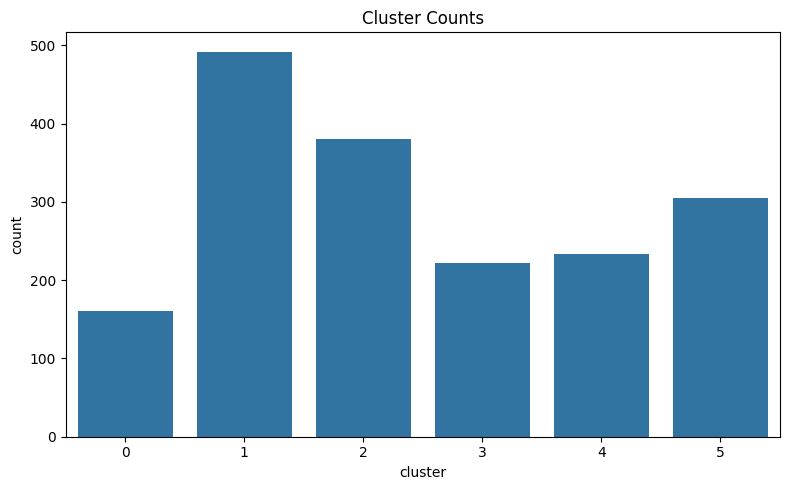

In [6]:
plt.figure(figsize=(8,5))
sns.countplot(data=all_df, x="cluster")
plt.title("Cluster Counts")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "cluster_counts.png", dpi=300)
plt.show()

In [7]:
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(sentence_embeddings)

all_df["pca_x"] = emb_2d[:, 0]
all_df["pca_y"] = emb_2d[:, 1]

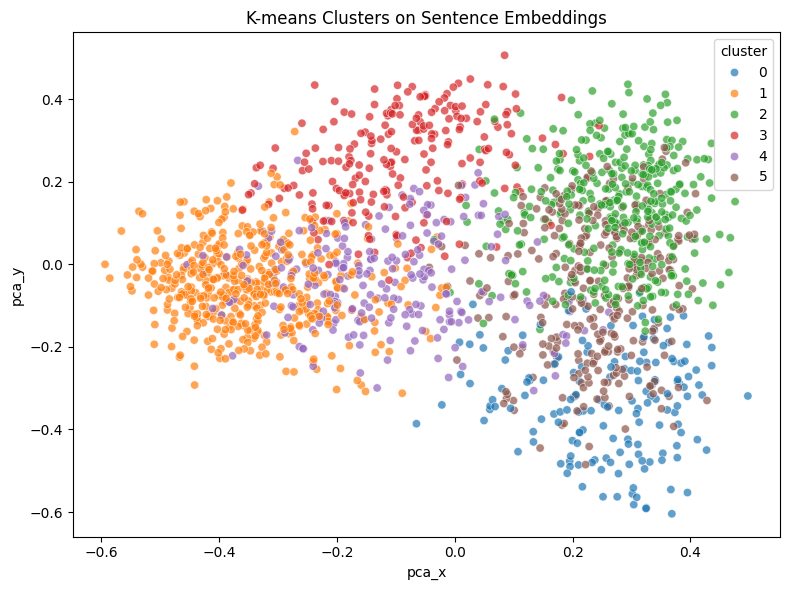

In [8]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=all_df, x="pca_x", y="pca_y", hue="cluster", palette="tab10", alpha=0.7)
plt.title("K-means Clusters on Sentence Embeddings")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "cluster_projection.png", dpi=300)
plt.show()

In [9]:
for c in sorted(all_df["cluster"].unique()):
    print(f"\n===== CLUSTER {c} =====")
    samples = all_df[all_df["cluster"] == c]["cleaned_text"].head(5).tolist()
    for i, s in enumerate(samples, 1):
        print(f"{i}. {s[:300]}")


===== CLUSTER 0 =====
1. Cave-inhabiting animals are often categorized as troglobites (cave-limited species), troglophiles (species that can live their entire lives in caves, but also occur in other environments), trogloxenes (species that use caves, but cannot complete their life cycle fully in caves) and accidentals (anim
2. Of these animals, the troglobites are perhaps the most unusual organisms. Troglobitic species often show a number of characteristics, termed troglomorphic, associated with their adaptation to subterranean life. These characteristics may include a loss of pigment (often resulting in a pale or white c
3. Because of the fragility of cave ecosystems, and the fact that cave regions tend to be isolated from one another, caves harbor a number of endangered species, such as the Tooth cave spider, liphistius trapdoor spider, and the gray bat.
4. Coral belongs to the class Anthozoa in the animal phylum Cnidaria, which includes sea anemones and jellyfish. Unlike sea anemon

In [10]:
cluster_name_map = {
    0: "dry_exposed",
    1: "frozen_quiet",
    2: "lush_dense",
    3: "flowing_unstable",
    4: "rocky_vertical",
    5: "atmospheric_abstract"
}

In [11]:
all_df["cluster_name"] = all_df["cluster"].map(cluster_name_map)
all_df.head()

,dataset,source,page_title,text_id,raw_text,cleaned_text,word_count,dataset_label,cluster,pca_x,pca_y,cluster_name
0,landforms,wikipedia,Desert,Desert_0,A desert is a landscape where little precipita...,A desert is a landscape where little precipita...,91,landforms,5,0.371352,0.011644,atmospheric_abstract
1,landforms,wikipedia,Desert,Desert_1,Deserts are formed by weathering processes as ...,Deserts are formed by weathering processes as ...,218,landforms,5,0.358664,0.273669,atmospheric_abstract
2,landforms,wikipedia,Desert,Desert_2,Plants and animals living in the desert need s...,Plants and animals living in the desert need s...,147,landforms,5,0.173692,-0.226674,atmospheric_abstract
3,landforms,wikipedia,Desert,Desert_3,People have struggled to live in deserts and t...,People have struggled to live in deserts and t...,151,landforms,5,0.042568,-0.075830,atmospheric_abstract
4,landforms,wikipedia,Desert,Desert_4,English desert and its Romance cognates (inclu...,English desert and its Romance cognates (inclu...,131,landforms,5,0.096850,-0.023956,atmospheric_abstract


In [12]:
all_df.to_csv(PROCESSED_DIR / "texts_with_clusters.csv", index=False)